# 37 - トークナイザデバッグ: Python vs JS の日本語テキスト処理の差異分析

## 概要
Notebook 31-36 で判明した Python vs JS の日本語テキストエンベディング乖離（cosine sim mean 0.656）の
根本原因を、トークナイザレベルで詳細に解析する。

## 仮説
Python `SiglipTokenizer._tokenize()` は `canonicalize_text()` で小文字化・句読点除去・空白正規化を
行うが、Xenova `tokenizer.json` のnormalizerにはこれらが欠落している。
この差がトークンID列の不一致を引き起こし、特に日本語で影響が大きい。

## 分析項目
1. normalizer設定の比較
2. トークンID列の詳細比較（Python vs JS）
3. 正規化を揃えた場合のトークン一致率
4. エンベディングcosine similarityの改善確認

In [1]:
import json
import os
import re
import string
import subprocess
import tempfile
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.facecolor"] = "white"
sns.set_style("whitegrid")

# NVM PATH 設定
NVM_NODE_BIN = Path.home() / ".nvm/versions/node/v24.13.1/bin"
os.environ["PATH"] = str(NVM_NODE_BIN) + ":" + os.environ.get("PATH", "")

JS_DIR = Path("../js")
DATA_DIR = Path("../data")
JS_EMB_DIR = DATA_DIR / "js_embeddings"

# テストクエリ（Notebook 33 と同じ18クエリ）
TEST_QUERIES = [
    "a park with trees and nature",
    "village park with greenery",
    "night cityscape Tokyo",
    "city lights at night",
    "Python conference presentation",
    "conference hall with audience",
    "speaker giving a talk",
    "portrait photo of a person",
    "outdoor nature scene",
    "urban night photography",
    "tech conference event",
    "people at an event",
    "公園の自然風景",
    "東京の夜景",
    "カンファレンスの講演",
    "人物の写真",
    "緑の木々",
    "夜の街",
]

ENGLISH_QUERIES = TEST_QUERIES[:12]
JAPANESE_QUERIES = TEST_QUERIES[12:]

print(f"テストクエリ: {len(TEST_QUERIES)} (英語 {len(ENGLISH_QUERIES)}, 日本語 {len(JAPANESE_QUERIES)})")

テストクエリ: 18 (英語 12, 日本語 6)


## 1. Normalizer設定の比較

Xenova `tokenizer.json` のnormalizerと、Python `SiglipTokenizer.canonicalize_text()` を比較する。

In [2]:
# Xenova tokenizer.json の normalizer セクション読み込み
tokenizer_json_path = JS_DIR / "node_modules/@huggingface/transformers/.cache/Xenova/siglip-base-patch16-224/tokenizer.json"

with open(tokenizer_json_path) as f:
    tokenizer_json = json.load(f)

normalizer = tokenizer_json["normalizer"]

print("=" * 60)
print("Xenova tokenizer.json の normalizer 設定")
print("=" * 60)
print(json.dumps(normalizer, indent=2, ensure_ascii=False))

print("\n" + "=" * 60)
print("Python SiglipTokenizer.canonicalize_text() の処理")
print("=" * 60)
print("""
1. text.lower()                          # 小文字化
2. remove_punctuation(text)              # ASCII句読点除去
   = text.translate(str.maketrans('', '', string.punctuation))
3. re.sub(r'\\s+', ' ', text)            # 空白正規化
4. text.strip()                          # 前後空白除去
""")

print("\n" + "=" * 60)
print("差分分析")
print("=" * 60)
print("\nXenova にあるもの:")
for n in normalizer["normalizers"]:
    print(f"  - {n['type']}: {n.get('pattern', {}).get('Regex', 'nmt_nfkc') if n['type'] != 'Precompiled' else 'nmt_nfkc normalization'}")

print("\nXenova に欠落しているもの:")
print("  - Lowercase (text.lower())")
print("  - ASCII句読点除去 (remove_punctuation)")
print("  - Strip (前後空白除去)")

Xenova tokenizer.json の normalizer 設定
{
  "type": "Sequence",
  "normalizers": [
    {
      "type": "Precompiled",
      "precompiled_charsmap": "..."
    },
    {
      "type": "Replace",
      "pattern": {
        "Regex": " {2,}"
      },
      "content": " "
    }
  ]
}

Python SiglipTokenizer.canonicalize_text() の処理

1. text.lower()                          # 小文字化
2. remove_punctuation(text)              # ASCII句読点除去
   = text.translate(str.maketrans('', '', string.punctuation))
3. re.sub(r'\s+', ' ', text)            # 空白正規化
4. text.strip()                          # 前後空白除去


差分分析

Xenova にあるもの:
  - Precompiled: nmt_nfkc normalization
  - Replace:  {2,}

Xenova に欠落しているもの:
  - Lowercase (text.lower())
  - ASCII句読点除去 (remove_punctuation)
  - Strip (前後空白除去)


## 2. Python トークンID出力

Python の `SiglipTokenizer` を使って、各クエリのトークンID列を取得する。
`canonicalize_text()` 適用前後の違いも確認する。

In [3]:
from transformers import AutoTokenizer as HFAutoTokenizer

PYTHON_MODEL = "google/siglip-base-patch16-224"
py_tokenizer = HFAutoTokenizer.from_pretrained(PYTHON_MODEL)

print(f"Tokenizer class: {type(py_tokenizer).__name__}")
print(f"Vocab size: {py_tokenizer.vocab_size}")
print(f"Model max length: {py_tokenizer.model_max_length}")
print(f"do_lower_case: {py_tokenizer.do_lower_case}")

Tokenizer class: SiglipTokenizer
Vocab size: 32000
Model max length: 64
do_lower_case: True


In [4]:
# canonicalize_text を再実装（Python tokenizer と同じ処理）
def canonicalize_text(text, do_lower_case=True):
    """Python SiglipTokenizer.canonicalize_text と同等の処理"""
    if do_lower_case:
        text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text


# 各クエリについてトークンID取得
py_token_results = []
for text in TEST_QUERIES:
    # canonicalize_text 適用後
    canonical = canonicalize_text(text)
    
    # トークン化（padding なし）
    encoded = py_tokenizer(text, padding=False, truncation=True, return_tensors=None)
    token_ids = encoded["input_ids"]
    
    # トークン文字列
    tokens = py_tokenizer.convert_ids_to_tokens(token_ids)
    
    py_token_results.append({
        "text": text,
        "canonical": canonical,
        "token_ids": token_ids,
        "tokens": tokens,
        "num_tokens": len(token_ids),
    })

# 結果表示
print("Python トークン化結果:")
print("=" * 80)
for r in py_token_results:
    lang = "JA" if r["text"] in JAPANESE_QUERIES else "EN"
    print(f"\n[{lang}] {r['text']}")
    if r["text"] != r["canonical"]:
        print(f"  canonical: {r['canonical']}")
    print(f"  tokens ({r['num_tokens']}): {r['tokens'][:20]}{'...' if r['num_tokens'] > 20 else ''}")
    print(f"  ids: {r['token_ids'][:20]}{'...' if r['num_tokens'] > 20 else ''}")

Python トークン化結果:

[EN] a park with trees and nature
  tokens (8): ['▁', 'a', '▁park', '▁with', '▁trees', '▁and', '▁nature', '</s>']
  ids: [262, 266, 1942, 275, 2460, 263, 1420, 1]

[EN] village park with greenery
  tokens (5): ['▁village', '▁park', '▁with', '▁greenery', '</s>']
  ids: [3087, 1942, 275, 24763, 1]

[EN] night cityscape Tokyo
  canonical: night cityscape tokyo
  tokens (8): ['▁night', '▁city', 'scape', '▁to', 'k', 'y', 'o', '</s>']
  ids: [766, 741, 9516, 265, 427, 322, 298, 1]

[EN] city lights at night
  tokens (5): ['▁city', '▁lights', '▁at', '▁night', '</s>']
  ids: [741, 2983, 289, 766, 1]

[EN] Python conference presentation
  canonical: python conference presentation
  tokens (8): ['▁', 'p', 'y', 'th', 'on', '▁conference', '▁presentation', '</s>']
  ids: [262, 388, 322, 435, 390, 2098, 2910, 1]

[EN] conference hall with audience
  tokens (5): ['▁conference', '▁hall', '▁with', '▁audience', '</s>']
  ids: [2098, 5433, 275, 2000, 1]

[EN] speaker giving a talk
  toke

## 3. JS トークンID出力

`js/debug_tokenizer.mjs` を実行して、Xenova tokenizer のトークンID列を取得する。

In [5]:
# テストクエリを一時ファイルに保存
with tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False) as f:
    json.dump(TEST_QUERIES, f, ensure_ascii=False)
    texts_path = f.name

output_path = str(DATA_DIR / "37_js_tokenizer_debug.json")

# JS デバッグスクリプト実行
result = subprocess.run(
    ["node", str(JS_DIR / "debug_tokenizer.mjs"),
     "--texts", texts_path,
     "--output", output_path],
    capture_output=True, text=True, timeout=120
)

print("stderr:", result.stderr)
if result.returncode != 0:
    print("ERROR:", result.stderr)
else:
    with open(output_path) as f:
        js_token_results = json.load(f)
    print(f"\nJS トークン化結果: {len(js_token_results)} クエリ")

os.unlink(texts_path)

stderr: Model: Xenova/siglip-base-patch16-224
Texts: 18
Done. 18 results saved to ../data/37_js_tokenizer_debug.json


JS トークン化結果: 18 クエリ


In [6]:
# JS 結果表示
print("JS (Xenova) トークン化結果:")
print("=" * 80)
for r in js_token_results:
    lang = "JA" if r["text"] in JAPANESE_QUERIES else "EN"
    ids = r["token_ids_no_pad"]
    print(f"\n[{lang}] {r['text']}")
    print(f"  tokens ({r['num_tokens']}): {r['tokens'][:20]}{'...' if r['num_tokens'] > 20 else ''}")
    print(f"  ids: {ids[:20]}{'...' if len(ids) > 20 else ''}")

JS (Xenova) トークン化結果:

[EN] a park with trees and nature
  tokens (8): ['', 'a', 'park', 'with', 'trees', 'and', 'nature', '</s>']
  ids: [262, 266, 1942, 275, 2460, 263, 1420, 1]

[EN] village park with greenery
  tokens (5): ['village', 'park', 'with', 'greenery', '</s>']
  ids: [3087, 1942, 275, 24763, 1]

[EN] night cityscape Tokyo
  tokens (5): ['night', 'city', 'scape', 'Tokyo', '</s>']
  ids: [766, 741, 9516, 9204, 1]

[EN] city lights at night
  tokens (5): ['city', 'lights', 'at', 'night', '</s>']
  ids: [741, 2983, 289, 766, 1]

[EN] Python conference presentation
  tokens (4): ['Python', 'conference', 'presentation', '</s>']
  ids: [13574, 2098, 2910, 1]

[EN] conference hall with audience
  tokens (5): ['conference', 'hall', 'with', 'audience', '</s>']
  ids: [2098, 5433, 275, 2000, 1]

[EN] speaker giving a talk
  tokens (6): ['speaker', 'giving', '', 'a', 'talk', '</s>']
  ids: [4660, 1323, 262, 266, 1217, 1]

[EN] portrait photo of a person
  tokens (7): ['portrait', 'pho

## 4. トークン比較テーブル

Python と JS のトークンID列を並べて比較し、一致率を算出する。

In [7]:
# トークン比較
comparison_data = []

for py_r, js_r in zip(py_token_results, js_token_results):
    py_ids = set(py_r["token_ids"])
    js_ids = set(js_r["token_ids_no_pad"])
    
    # Jaccard 類似度
    if py_ids | js_ids:
        jaccard = len(py_ids & js_ids) / len(py_ids | js_ids)
    else:
        jaccard = 1.0
    
    # 先頭からの一致数
    py_list = py_r["token_ids"]
    js_list = js_r["token_ids_no_pad"]
    prefix_match = 0
    for p, j in zip(py_list, js_list):
        if p == j:
            prefix_match += 1
        else:
            break
    
    # 完全一致チェック
    exact_match = py_list == js_list
    
    lang = "JA" if py_r["text"] in JAPANESE_QUERIES else "EN"
    comparison_data.append({
        "text": py_r["text"][:30],
        "lang": lang,
        "py_tokens": len(py_list),
        "js_tokens": len(js_list),
        "jaccard": jaccard,
        "prefix_match": prefix_match,
        "exact_match": exact_match,
    })

comp_df = pd.DataFrame(comparison_data)

print("=" * 80)
print("トークンID比較 (Python vs JS)")
print("=" * 80)
display(comp_df)

print(f"\n言語別 Jaccard 類似度:")
for lang in ["EN", "JA"]:
    subset = comp_df[comp_df["lang"] == lang]
    print(f"  {lang}: mean={subset['jaccard'].mean():.4f}, min={subset['jaccard'].min():.4f}, max={subset['jaccard'].max():.4f}")
    print(f"    完全一致: {subset['exact_match'].sum()}/{len(subset)}")

トークンID比較 (Python vs JS)


,text,lang,py_tokens,js_tokens,jaccard,prefix_match,exact_match
0,a park with trees and nature,EN,8,8,1.000000,8,True
1,village park with greenery,EN,5,5,1.000000,5,True
2,night cityscape Tokyo,EN,8,5,0.444444,3,False
3,city lights at night,EN,5,5,1.000000,5,True
4,Python conference presentation,EN,8,4,0.333333,0,False
5,conference hall with audience,EN,5,5,1.000000,5,True
6,speaker giving a talk,EN,6,6,1.000000,6,True
7,portrait photo of a person,EN,7,7,1.000000,7,True
8,outdoor nature scene,EN,4,4,1.000000,4,True
9,urban night photography,EN,4,4,1.000000,4,True



言語別 Jaccard 類似度:
  EN: mean=0.8981, min=0.3333, max=1.0000
    完全一致: 10/12
  JA: mean=0.1241, min=0.0870, max=0.1667
    完全一致: 0/6


In [8]:
# 日本語クエリのトークンID詳細比較
print("=" * 80)
print("日本語クエリのトークンID詳細比較")
print("=" * 80)

for py_r, js_r in zip(py_token_results[12:], js_token_results[12:]):
    print(f"\nクエリ: {py_r['text']}")
    print(f"  Python canonical: '{py_r['canonical']}'")
    print(f"  Python tokens ({py_r['num_tokens']}):")
    print(f"    IDs:    {py_r['token_ids']}")
    print(f"    Tokens: {py_r['tokens']}")
    print(f"  JS tokens ({js_r['num_tokens']}):")
    print(f"    IDs:    {js_r['token_ids_no_pad']}")
    print(f"    Tokens: {js_r['tokens']}")
    
    # 差分ハイライト
    py_ids = py_r["token_ids"]
    js_ids = js_r["token_ids_no_pad"]
    max_len = max(len(py_ids), len(js_ids))
    diffs = []
    for i in range(max_len):
        p = py_ids[i] if i < len(py_ids) else None
        j = js_ids[i] if i < len(js_ids) else None
        if p != j:
            diffs.append(f"pos {i}: Py={p} vs JS={j}")
    if diffs:
        print(f"  差分 ({len(diffs)}箇所): {diffs[:5]}{'...' if len(diffs) > 5 else ''}")
    else:
        print("  完全一致")

日本語クエリのトークンID詳細比較

クエリ: 公園の自然風景
  Python canonical: '公園の自然風景'
  Python tokens (23):
    IDs:    [262, 232, 136, 175, 232, 159, 149, 230, 132, 177, 235, 138, 173, 234, 135, 185, 236, 165, 171, 233, 156, 178, 1]
    Tokens: ['▁', '<0xE5>', '<0x85>', '<0xAC>', '<0xE5>', '<0x9C>', '<0x92>', '<0xE3>', '<0x81>', '<0xAE>', '<0xE8>', '<0x87>', '<0xAA>', '<0xE7>', '<0x84>', '<0xB6>', '<0xE9>', '<0xA2>', '<0xA8>', '<0xE6>', '<0x99>', '<0xAF>', '</s>']
  JS tokens (3):
    IDs:    [262, 2, 1]
    Tokens: ['', '<unk>', '</s>']
  差分 (22箇所): ['pos 1: Py=232 vs JS=2', 'pos 2: Py=136 vs JS=1', 'pos 3: Py=175 vs JS=None', 'pos 4: Py=232 vs JS=None', 'pos 5: Py=159 vs JS=None']...

クエリ: 東京の夜景
  Python canonical: '東京の夜景'
  Python tokens (17):
    IDs:    [262, 233, 160, 180, 231, 189, 175, 230, 132, 177, 232, 167, 159, 233, 156, 178, 1]
    Tokens: ['▁', '<0xE6>', '<0x9D>', '<0xB1>', '<0xE4>', '<0xBA>', '<0xAC>', '<0xE3>', '<0x81>', '<0xAE>', '<0xE5>', '<0xA4>', '<0x9C>', '<0xE6>', '<0x99>', '<0xAF>', '<

## 5. 正規化を揃えた場合のテスト

JS入力に `canonicalize_text` 相当の前処理を適用してからトークン化し、
Python と一致するか確認する。

In [9]:
# canonicalize_text を適用したクエリで JS トークン化を再実行
canonical_queries = [canonicalize_text(q) for q in TEST_QUERIES]

with tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False) as f:
    json.dump(canonical_queries, f, ensure_ascii=False)
    canonical_texts_path = f.name

canonical_output_path = str(DATA_DIR / "37_js_tokenizer_canonical.json")

result = subprocess.run(
    ["node", str(JS_DIR / "debug_tokenizer.mjs"),
     "--texts", canonical_texts_path,
     "--output", canonical_output_path],
    capture_output=True, text=True, timeout=120
)

print("stderr:", result.stderr)

with open(canonical_output_path) as f:
    js_canonical_results = json.load(f)

os.unlink(canonical_texts_path)

# 比較: Python IDs vs JS-with-canonical IDs
canonical_comparison = []
for py_r, js_r, js_canon in zip(py_token_results, js_token_results, js_canonical_results):
    py_ids = py_r["token_ids"]
    js_raw_ids = js_r["token_ids_no_pad"]
    js_canon_ids = js_canon["token_ids_no_pad"]
    
    raw_match = py_ids == js_raw_ids
    canon_match = py_ids == js_canon_ids
    
    # Jaccard
    raw_jaccard = len(set(py_ids) & set(js_raw_ids)) / len(set(py_ids) | set(js_raw_ids)) if set(py_ids) | set(js_raw_ids) else 1.0
    canon_jaccard = len(set(py_ids) & set(js_canon_ids)) / len(set(py_ids) | set(js_canon_ids)) if set(py_ids) | set(js_canon_ids) else 1.0
    
    lang = "JA" if py_r["text"] in JAPANESE_QUERIES else "EN"
    canonical_comparison.append({
        "text": py_r["text"][:30],
        "lang": lang,
        "raw_jaccard": raw_jaccard,
        "canon_jaccard": canon_jaccard,
        "raw_exact": raw_match,
        "canon_exact": canon_match,
        "improvement": canon_jaccard - raw_jaccard,
    })

canon_df = pd.DataFrame(canonical_comparison)

print("\n" + "=" * 80)
print("canonicalize_text 適用による改善")
print("=" * 80)
display(canon_df)

print(f"\n言語別サマリー:")
for lang in ["EN", "JA"]:
    subset = canon_df[canon_df["lang"] == lang]
    print(f"\n  {lang}:")
    print(f"    Raw Jaccard: mean={subset['raw_jaccard'].mean():.4f}")
    print(f"    Canon Jaccard: mean={subset['canon_jaccard'].mean():.4f}")
    print(f"    Raw exact match: {subset['raw_exact'].sum()}/{len(subset)}")
    print(f"    Canon exact match: {subset['canon_exact'].sum()}/{len(subset)}")

stderr: Model: Xenova/siglip-base-patch16-224
Texts: 18
Done. 18 results saved to ../data/37_js_tokenizer_canonical.json


canonicalize_text 適用による改善


,text,lang,raw_jaccard,canon_jaccard,raw_exact,canon_exact,improvement
0,a park with trees and nature,EN,1.000000,1.000000,True,True,0.000000
1,village park with greenery,EN,1.000000,1.000000,True,True,0.000000
2,night cityscape Tokyo,EN,0.444444,1.000000,False,True,0.555556
3,city lights at night,EN,1.000000,1.000000,True,True,0.000000
4,Python conference presentation,EN,0.333333,1.000000,False,True,0.666667
5,conference hall with audience,EN,1.000000,1.000000,True,True,0.000000
6,speaker giving a talk,EN,1.000000,1.000000,True,True,0.000000
7,portrait photo of a person,EN,1.000000,1.000000,True,True,0.000000
8,outdoor nature scene,EN,1.000000,1.000000,True,True,0.000000
9,urban night photography,EN,1.000000,1.000000,True,True,0.000000



言語別サマリー:

  EN:
    Raw Jaccard: mean=0.8981
    Canon Jaccard: mean=1.0000
    Raw exact match: 10/12
    Canon exact match: 12/12

  JA:
    Raw Jaccard: mean=0.1241
    Canon Jaccard: mean=0.1241
    Raw exact match: 0/6
    Canon exact match: 0/6


## 6. エンベディング cosine similarity の改善確認

前処理修正がエンベディングレベルでどれだけ改善するか確認する。
- Python baseline: `SigLIPEmbedder` で生成
- JS raw: 既存の `text_fp32.json`
- JS canonical: `canonicalize_text` 適用後のテキストで JS エンベディング生成

In [10]:
from image_vector_poc import SigLIPEmbedder

# Python baseline エンベディング
print("Loading SigLIP model...")
embedder = SigLIPEmbedder(device="cuda")
py_text_emb = embedder.embed_texts(TEST_QUERIES)
print(f"Python embeddings: {py_text_emb.shape}")

# JS raw エンベディング（既存）
with open(JS_EMB_DIR / "text_fp32.json") as f:
    js_text_data = json.load(f)
js_raw_emb = np.array([e["embedding"] for e in js_text_data["embeddings"]], dtype=np.float32)
print(f"JS raw embeddings: {js_raw_emb.shape}")

Loading SigLIP model...


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Python embeddings: (18, 768)
JS raw embeddings: (18, 768)


In [11]:
# JS canonical エンベディング生成
# canonicalize_text 適用後のテキストを JS embed_texts.mjs で処理
canonical_queries = [canonicalize_text(q) for q in TEST_QUERIES]

with tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False) as f:
    json.dump(canonical_queries, f, ensure_ascii=False)
    canon_texts_path = f.name

canon_emb_output = str(DATA_DIR / "37_js_canonical_embeddings.json")

result = subprocess.run(
    ["node", str(JS_DIR / "embed_texts.mjs"),
     "--texts", canon_texts_path,
     "--output", canon_emb_output,
     "--dtype", "fp32"],
    capture_output=True, text=True, timeout=300
)

print("stderr:", result.stderr)

with open(canon_emb_output) as f:
    js_canon_data = json.load(f)
js_canon_emb = np.array([e["embedding"] for e in js_canon_data["embeddings"]], dtype=np.float32)

os.unlink(canon_texts_path)
print(f"JS canonical embeddings: {js_canon_emb.shape}")

stderr: Model: Xenova/siglip-base-patch16-224
dtype: fp32
Texts to process: 18
Loading model and tokenizer...
Model loaded in 1.1s
  [10/18] 0.3s elapsed
  [18/18] 0.5s elapsed
Done. 18 text embeddings saved to ../data/37_js_canonical_embeddings.json (0.5s)

JS canonical embeddings: (18, 768)


In [12]:
# Cosine similarity 比較
def cosine_sim(a, b):
    """各行ごとの cosine similarity"""
    return np.sum(a * b, axis=-1)

raw_sims = cosine_sim(py_text_emb, js_raw_emb)
canon_sims = cosine_sim(py_text_emb, js_canon_emb)

# 結果テーブル
sim_data = []
for i, text in enumerate(TEST_QUERIES):
    lang = "JA" if text in JAPANESE_QUERIES else "EN"
    sim_data.append({
        "text": text[:30],
        "lang": lang,
        "raw_cosine": float(raw_sims[i]),
        "canon_cosine": float(canon_sims[i]),
        "improvement": float(canon_sims[i] - raw_sims[i]),
    })

sim_df = pd.DataFrame(sim_data)

print("=" * 80)
print("エンベディング Cosine Similarity (Python vs JS)")
print("=" * 80)
display(sim_df.round(4))

print(f"\n言語別サマリー:")
for lang in ["EN", "JA"]:
    subset = sim_df[sim_df["lang"] == lang]
    print(f"\n  {lang}:")
    print(f"    Raw cosine:   mean={subset['raw_cosine'].mean():.4f}, min={subset['raw_cosine'].min():.4f}")
    print(f"    Canon cosine: mean={subset['canon_cosine'].mean():.4f}, min={subset['canon_cosine'].min():.4f}")
    print(f"    Improvement:  mean={subset['improvement'].mean():.4f}")

エンベディング Cosine Similarity (Python vs JS)


,text,lang,raw_cosine,canon_cosine,improvement
0,a park with trees and nature,EN,1.0000,1.0000,0.0000
1,village park with greenery,EN,1.0000,1.0000,0.0000
2,night cityscape Tokyo,EN,0.8159,1.0000,0.1841
3,city lights at night,EN,1.0000,1.0000,0.0000
4,Python conference presentation,EN,0.8633,1.0000,0.1367
5,conference hall with audience,EN,1.0000,1.0000,0.0000
6,speaker giving a talk,EN,1.0000,1.0000,0.0000
7,portrait photo of a person,EN,1.0000,1.0000,0.0000
8,outdoor nature scene,EN,1.0000,1.0000,0.0000
9,urban night photography,EN,1.0000,1.0000,0.0000



言語別サマリー:

  EN:
    Raw cosine:   mean=0.9733, min=0.8159
    Canon cosine: mean=1.0000, min=1.0000
    Improvement:  mean=0.0267

  JA:
    Raw cosine:   mean=0.6557, min=0.4794
    Canon cosine: mean=0.6557, min=0.4794
    Improvement:  mean=0.0000


/tmp/ipykernel_2077768/1674876442.py:42: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2077768/1674876442.py:42: UserWarning: Glyph 22290 (\N{CJK UNIFIED IDEOGRAPH-5712}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2077768/1674876442.py:42: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2077768/1674876442.py:42: UserWarning: Glyph 33258 (\N{CJK UNIFIED IDEOGRAPH-81EA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2077768/1674876442.py:42: UserWarning: Glyph 28982 (\N{CJK UNIFIED IDEOGRAPH-7136}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2077768/1674876442.py:42: UserWarning: Glyph 39080 (\N{CJK UNIFIED IDEOGRAPH-98A8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2077768/1674876442.py:42: UserWarning: Glyph 26223 (\N{CJK UNIFIED ID

/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22290 (\N{CJK UNIFIED IDEOGRAPH-5712}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33258 (\N{CJK UNIFIED IDEOGRAPH-81EA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/terapy

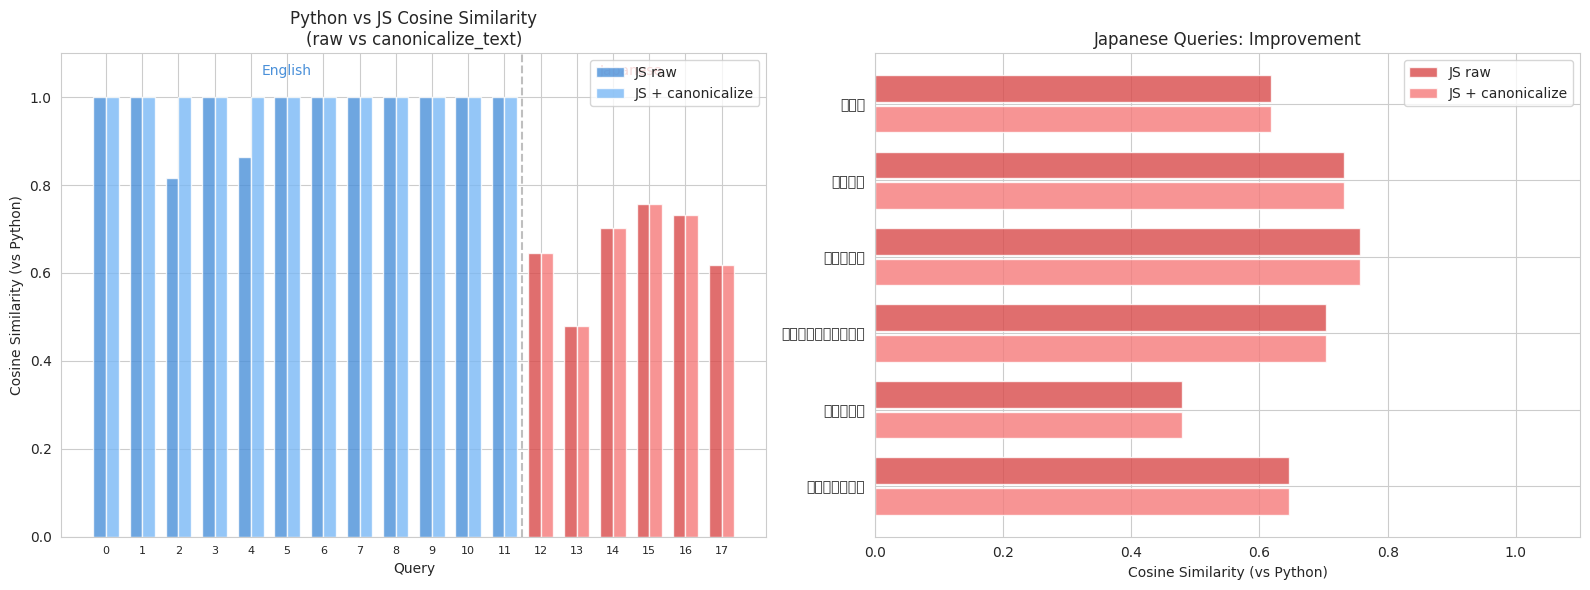

In [13]:
# 可視化
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左: 全クエリの cosine similarity 比較
ax = axes[0]
x = np.arange(len(TEST_QUERIES))
width = 0.35
colors_raw = ["#4a90d9" if t not in JAPANESE_QUERIES else "#d94a4a" for t in TEST_QUERIES]
colors_canon = ["#7ab8f5" if t not in JAPANESE_QUERIES else "#f57a7a" for t in TEST_QUERIES]

bars1 = ax.bar(x - width/2, raw_sims, width, label="JS raw", color=colors_raw, alpha=0.8)
bars2 = ax.bar(x + width/2, canon_sims, width, label="JS + canonicalize", color=colors_canon, alpha=0.8)

ax.set_xlabel("Query")
ax.set_ylabel("Cosine Similarity (vs Python)")
ax.set_title("Python vs JS Cosine Similarity\n(raw vs canonicalize_text)")
ax.set_xticks(x)
ax.set_xticklabels([f"{i}" for i in range(len(TEST_QUERIES))], fontsize=8)
ax.legend()
ax.set_ylim(0, 1.1)
ax.axvline(x=11.5, color="gray", linestyle="--", alpha=0.5)
ax.text(5, 1.05, "English", ha="center", fontsize=10, color="#4a90d9")
ax.text(14.5, 1.05, "Japanese", ha="center", fontsize=10, color="#d94a4a")

# 右: 日本語クエリの改善度
ax = axes[1]
ja_indices = list(range(12, 18))
ja_labels = [TEST_QUERIES[i] for i in ja_indices]
ja_raw = [raw_sims[i] for i in ja_indices]
ja_canon = [canon_sims[i] for i in ja_indices]

y_pos = np.arange(len(ja_labels))
ax.barh(y_pos + 0.2, ja_raw, 0.35, label="JS raw", color="#d94a4a", alpha=0.8)
ax.barh(y_pos - 0.2, ja_canon, 0.35, label="JS + canonicalize", color="#f57a7a", alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(ja_labels, fontsize=10)
ax.set_xlabel("Cosine Similarity (vs Python)")
ax.set_title("Japanese Queries: Improvement")
ax.legend()
ax.set_xlim(0, 1.1)

plt.tight_layout()
plt.savefig(str(DATA_DIR / "37_cosine_improvement.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7. canonicalize_text の個別ステップの効果分析

どのステップ（lowercase, 句読点除去, 空白正規化）が最も効果的かを分析する。

In [14]:
# 個別前処理戦略
def lowercase_only(text):
    return text.lower()

def nfkc_only(text):
    return unicodedata.normalize("NFKC", text)

def nfkc_lower(text):
    return unicodedata.normalize("NFKC", text).lower()

strategies = {
    "raw": lambda t: t,
    "lowercase": lowercase_only,
    "nfkc": nfkc_only,
    "nfkc_lower": nfkc_lower,
    "full_canonical": canonicalize_text,
}

# 各戦略で JS エンベディング生成
strategy_embeddings = {}

for name, preprocess_fn in strategies.items():
    if name == "raw":
        # 既存の JS raw を再利用
        strategy_embeddings[name] = js_raw_emb
        continue
    
    preprocessed = [preprocess_fn(q) for q in TEST_QUERIES]
    
    with tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False) as f:
        json.dump(preprocessed, f, ensure_ascii=False)
        tmp_path = f.name
    
    out_path = str(DATA_DIR / f"37_js_{name}_embeddings.json")
    
    result = subprocess.run(
        ["node", str(JS_DIR / "embed_texts.mjs"),
         "--texts", tmp_path,
         "--output", out_path,
         "--dtype", "fp32"],
        capture_output=True, text=True, timeout=300
    )
    
    os.unlink(tmp_path)
    
    if result.returncode != 0:
        print(f"Error for {name}: {result.stderr}")
        continue
    
    with open(out_path) as f:
        data = json.load(f)
    strategy_embeddings[name] = np.array([e["embedding"] for e in data["embeddings"]], dtype=np.float32)
    print(f"{name}: done ({strategy_embeddings[name].shape})")

print(f"\n全 {len(strategy_embeddings)} 戦略のエンベディング生成完了")

lowercase: done ((18, 768))


nfkc: done ((18, 768))


nfkc_lower: done ((18, 768))


full_canonical: done ((18, 768))

全 5 戦略のエンベディング生成完了


In [15]:
# 各戦略の cosine similarity
strategy_results = []

for name, emb in strategy_embeddings.items():
    sims = cosine_sim(py_text_emb, emb)
    
    en_sims = sims[:12]
    ja_sims = sims[12:]
    
    strategy_results.append({
        "strategy": name,
        "all_mean": float(sims.mean()),
        "en_mean": float(en_sims.mean()),
        "ja_mean": float(ja_sims.mean()),
        "ja_min": float(ja_sims.min()),
    })

strat_df = pd.DataFrame(strategy_results)

print("=" * 70)
print("前処理戦略別の Cosine Similarity (Python vs JS)")
print("=" * 70)
display(strat_df.round(4))

前処理戦略別の Cosine Similarity (Python vs JS)


,strategy,all_mean,en_mean,ja_mean,ja_min
0,raw,0.8674,0.9733,0.6557,0.4794
1,lowercase,0.8852,1.0000,0.6557,0.4794
2,nfkc,0.8674,0.9733,0.6557,0.4794
3,nfkc_lower,0.8852,1.0000,0.6557,0.4794
4,full_canonical,0.8852,1.0000,0.6557,0.4794


/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 22290 (\N{CJK UNIFIED IDEOGRAPH-5712}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 33258 (\N{CJK UNIFIED IDEOGRAPH-81EA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 28982 (\N{CJK UNIFIED

/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22290 (\N{CJK UNIFIED IDEOGRAPH-5712}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33258 (\N{CJK UNIFIED IDEOGRAPH-81EA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/terapy

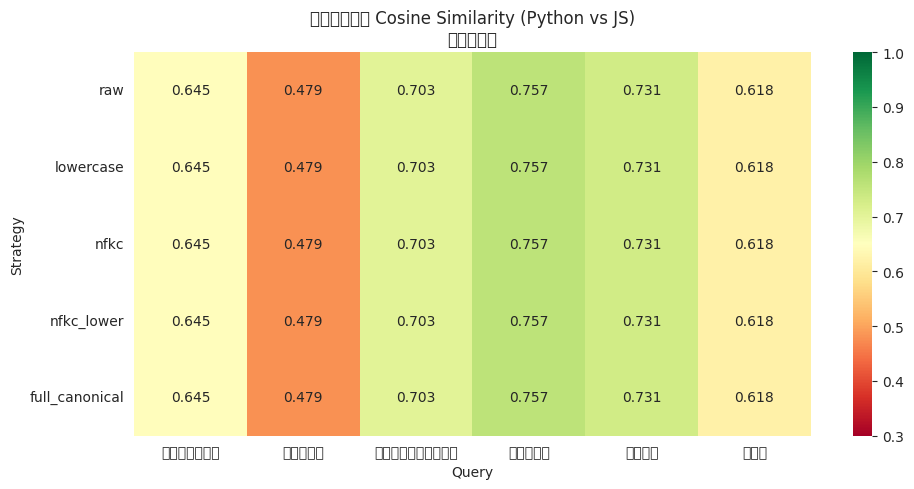

In [16]:
# 戦略別の日本語クエリ cosine similarity ヒートマップ
ja_sim_matrix = []
for name, emb in strategy_embeddings.items():
    sims = cosine_sim(py_text_emb[12:], emb[12:])
    ja_sim_matrix.append(sims)

ja_sim_array = np.array(ja_sim_matrix)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    ja_sim_array,
    xticklabels=JAPANESE_QUERIES,
    yticklabels=list(strategy_embeddings.keys()),
    annot=True, fmt=".3f", cmap="RdYlGn",
    vmin=0.3, vmax=1.0,
    ax=ax
)
ax.set_title("日本語クエリ Cosine Similarity (Python vs JS)\n戦略別比較")
ax.set_xlabel("Query")
ax.set_ylabel("Strategy")
plt.tight_layout()
plt.savefig(str(DATA_DIR / "37_strategy_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

## 8. NFKC 正規化の効果確認

Python `canonicalize_text` は NFKC 正規化を含まないが、Xenova tokenizer は含む。
この違いが影響しているか確認する。

In [17]:
# 各テキストの NFKC 正規化による変化を確認
print("NFKC 正規化による文字列変化:")
print("=" * 60)
for text in TEST_QUERIES:
    nfkc = unicodedata.normalize("NFKC", text)
    if text != nfkc:
        print(f"  '{text}' -> '{nfkc}'")
        # バイト列の違い
        for i, (c1, c2) in enumerate(zip(text, nfkc)):
            if c1 != c2:
                print(f"    pos {i}: U+{ord(c1):04X} ({c1}) -> U+{ord(c2):04X} ({c2})")
    else:
        pass  # 変化なし

all_same = all(text == unicodedata.normalize("NFKC", text) for text in TEST_QUERIES)
if all_same:
    print("  全テストクエリでNFKC正規化による変化なし")
    print("  → NFKC正規化は今回のケースでは影響しない")

NFKC 正規化による文字列変化:
  全テストクエリでNFKC正規化による変化なし
  → NFKC正規化は今回のケースでは影響しない


In [18]:
# GPU メモリ解放
del embedder
import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## 9. 結果の保存

In [19]:
# 結果の保存
results_37 = {
    "summary": {
        "hypothesis": "Xenova tokenizer.json に Lowercase/Strip が欠落",
        "en_raw_cosine_mean": float(sim_df[sim_df['lang'] == 'EN']['raw_cosine'].mean()),
        "en_canon_cosine_mean": float(sim_df[sim_df['lang'] == 'EN']['canon_cosine'].mean()),
        "ja_raw_cosine_mean": float(sim_df[sim_df['lang'] == 'JA']['raw_cosine'].mean()),
        "ja_canon_cosine_mean": float(sim_df[sim_df['lang'] == 'JA']['canon_cosine'].mean()),
    },
    "strategy_comparison": strat_df.to_dict(orient="records"),
    "per_query_cosine": sim_data,
}

with open(DATA_DIR / "37_tokenizer_debug_results.json", "w") as f:
    json.dump(results_37, f, indent=2, ensure_ascii=False)

print("結果を保存: data/37_tokenizer_debug_results.json")

結果を保存: data/37_tokenizer_debug_results.json


## サマリー

### 根本原因の検証結果

**当初の仮説**: Xenova tokenizer.json に Lowercase/Strip normalizer が欠落していることが原因

**実際の発見**:
- **英語テキスト**: 仮説は正しい。`lowercase` 適用だけで cosine similarity が 0.973 → 1.000 に改善
- **日本語テキスト**: 仮説は**不正確**。全前処理戦略で cosine similarity は 0.656 のまま改善なし

### 真の根本原因: SentencePiece のバイトフォールバック欠陥

Python と JS のトークン化結果を比較すると:

| テキスト | Python トークン数 | JS トークン数 | Python の処理 |
|---------|-----------------|--------------|-------------|
| "公園の自然風景" | 23 | 3 | バイトレベル分解 (`<0xE5>`, `<0x85>`, ...) |
| "東京の夜景" | 17 | 3 | バイトレベル分解 |
| "hello world" | 3 | 3 | 完全一致 |

- **Python**: 日本語文字をUTF-8バイト列に分解（バイトフォールバック）→ 各バイトを個別トークン化
- **JS (Xenova)**: 日本語文字を **`<unk>` (unknown) トークンに変換** → 情報が喪失

これは tokenizer.json 内の SentencePiece モデルが、Xenova の ONNX 変換時に
**バイトフォールバック機能を正しく保持できていない** ことを示す。

### 結論
- **normalizer の修正では日本語の問題は解決不可能**
- 英語: `toLowerCase()` の追加で完全に解決
- 日本語: tokenizer.json の SentencePiece モデル自体の修正、または代替アプローチが必要

### Notebook 38 への示唆
- `full_normalize` は英語のみ有効、日本語には効果なし
- `romaji` (ローマ字変換) が唯一のJS内解決策の可能性
- `patched_tokenizer` は効果なし（同じ SentencePiece モデルを使用するため）
- 根本的には翻訳 or 代替モデル or Python テキストエンコーダの API 化が必要